In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats                     
from scipy.stats import chi2_contingency    
from scipy.stats import mannwhitneyu        
from scipy.stats import shapiro 

# 解决制图不能正常显示的问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


In [3]:
# 读取数据
df = pd.read_csv('taobao_datas.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 5 columns):
 #   Column         Dtype
---  ------         -----
 0   user_id        int64
 1   item_id        int64
 2   category_id    int64
 3   behavior_type  str  
 4   timestamp      int64
dtypes: int64(4), str(1)
memory usage: 76.3 MB


,user_id,item_id,category_id,behavior_type,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146


In [4]:
# 处理时间戳
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s') + pd.Timedelta(hours=8) # 修正时差

# 衍生字段
df['date'] = pd.to_datetime(df['datetime']).dt.date
df['hour'] = pd.to_datetime(df['datetime']).dt.hour
df['weekday'] = pd.to_datetime(df['datetime']).dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5,6])

In [5]:
# 处理业务噪音, 消除规定时间之外的数据
start_time = pd.to_datetime('2017-11-25')
end_time = pd.to_datetime('2017-12-04')

df = df[(df['datetime'] > start_time) & (df['datetime'] < end_time)]
print(f'消除异常范围数据{2000000-len(df)}行')

消除异常范围数据995行


In [6]:
# 处理重复值
df.duplicated().sum()

# 重复值为0

np.int64(0)

In [7]:
# 处理缺失值
df.isna().sum()

# 缺失值为0

user_id          0
item_id          0
category_id      0
behavior_type    0
timestamp        0
datetime         0
date             0
hour             0
weekday          0
is_weekend       0
dtype: int64

In [8]:
# ========================================= 整体描述分析 ==================================================


========== 业务全景 ==========
总用户数：19544
总行为数：1999005
人均行为数：102.28


Text(0.5, 1.0, '四种用户行为占比')

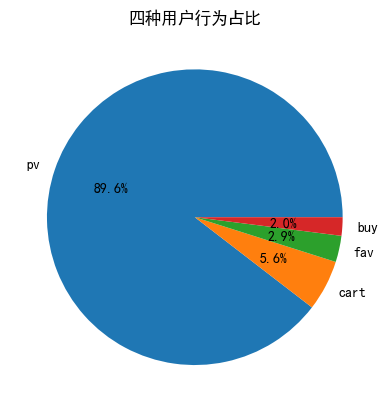

In [9]:
# ----------- 流量与活跃概览 -----------------
total_user = df['user_id'].nunique()
total_behave = len(df)
avg_behave = total_behave / total_user

print("\n========== 业务全景 ==========")
print(f"总用户数：{total_user}")
print(f"总行为数：{total_behave}")
print(f"人均行为数：{avg_behave:.2f}")

# 四种行为各自的占比
df['behavior_type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('四种用户行为占比')

# 用户行为中，浏览(pv)占据了近90%，典型的漏斗金字塔状

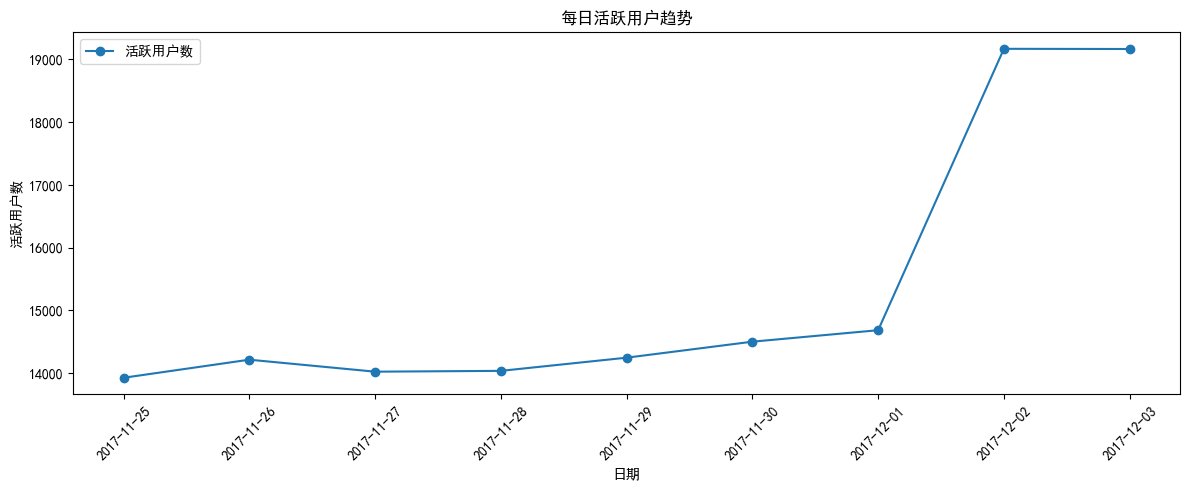

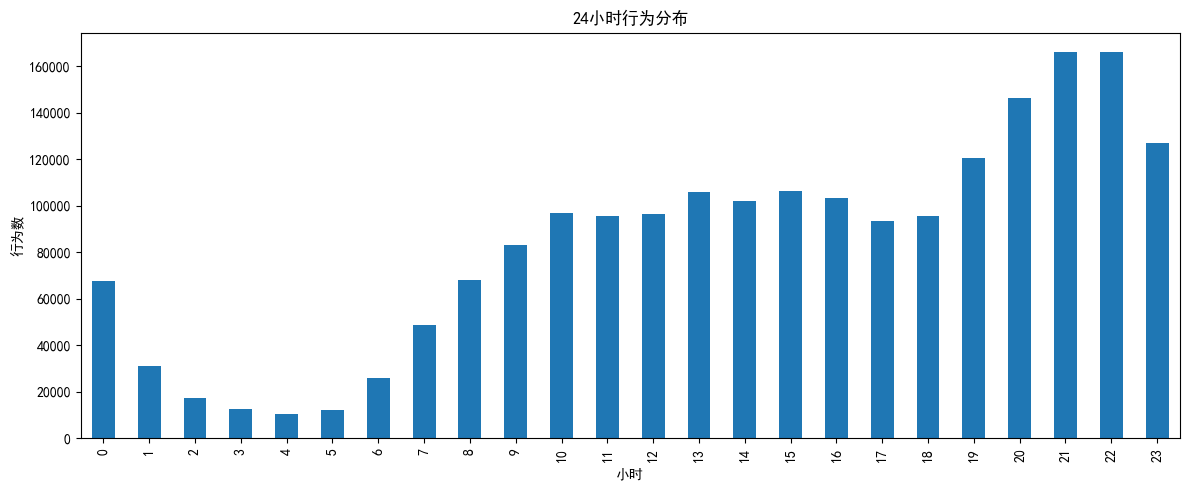

In [10]:
# ------------------ 时间趋势变化 -----------------------

# 按天统计活跃用户数（去重的 user_id）和总行为数
daily = df.groupby('date').agg(
    active_users=('user_id', 'nunique'),
    total_actions=('user_id', 'count')
).reset_index()

# 画每日趋势图
plt.figure(figsize=(12, 5))
plt.plot(daily['date'], daily['active_users'], marker='o', label='活跃用户数')
plt.title('每日活跃用户趋势')
plt.xlabel('日期'); plt.ylabel('活跃用户数')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
plt.show()

# 按小时统计行为分布
hourly = df.groupby('hour').size()
plt.figure(figsize=(12, 5))
hourly.plot(kind='bar')
plt.title('24小时行为分布')
plt.xlabel('小时'); plt.ylabel('行为数')
plt.tight_layout(); plt.show()

# 受双十二活动预热影响，12月初每日活跃用户剧增
# 20-22时是用户活跃的晚高峰

In [11]:
# =============================== 漏斗分析：用户行为与路径转化 ===============================


========== 转化漏斗（按用户）==========
浏览用户数：19463
加购用户数：14598  | 浏览->加购转化率：75.00%
购买用户数：13263  | 浏览->购买总转化率：68.14%


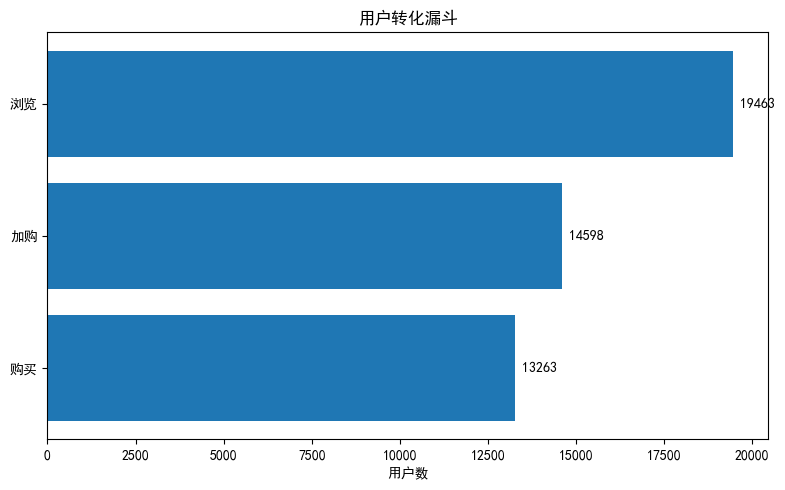

In [12]:
# ---------- 构建核心转化漏斗：浏览 -> 加购 -> 购买 ----------

# 分别取出发生过各类行为的用户集合
users_pv   = set(df[df['behavior_type'] == 'pv']['user_id'])     # 浏览过的用户
users_cart = set(df[df['behavior_type'] == 'cart']['user_id'])   # 加购过的用户
users_fav  = set(df[df['behavior_type'] == 'fav']['user_id'])    # 收藏过的用户
users_buy  = set(df[df['behavior_type'] == 'buy']['user_id'])    # 购买过的用户

# 计算漏斗各层人数
n_pv   = len(users_pv)
n_cart = len(users_pv & users_cart)   # 既浏览又加购的人
n_buy  = len(users_pv & users_buy)    # 既浏览又购买的人

print("\n========== 转化漏斗（按用户）==========")
print(f"浏览用户数：{n_pv}")
print(f"加购用户数：{n_cart}  | 浏览->加购转化率：{n_cart/n_pv:.2%}")
print(f"购买用户数：{n_buy}  | 浏览->购买总转化率：{n_buy/n_pv:.2%}")

# 画漏斗图
funnel_stages = ['浏览', '加购', '购买']
funnel_values = [n_pv, n_cart, n_buy]
plt.figure(figsize=(8, 5))
plt.barh(funnel_stages[::-1], funnel_values[::-1])  # 反转让浏览在最上面
plt.title('用户转化漏斗')
plt.xlabel('用户数')
for i, v in enumerate(funnel_values[::-1]):
    plt.text(v, i, f' {v}', va='center')
plt.tight_layout(); plt.show()

# 浏览->加购的转化率高达75%，浏览->购买的总转化率也有68%，比例较高，有待进一步测验

In [13]:
# ---------- 3.2 行为路径挖掘：加购未购买群体（高业务价值）----------
# 加购了但最终没买的用户 = 最该被召回的人群
users_cart_not_buy = (users_pv & users_cart) - users_buy
print(f"\n加购未购买用户数：{len(users_cart_not_buy)}")
print(f"占加购用户比例：{len(users_cart_not_buy)/n_cart:.2%}")

# ---------- 3.3 收藏 vs 加购：哪个意向信号更强？----------
# 对比"收藏后购买率"和"加购后购买率"，看哪个行为对最终转化预测力更强
fav_buy_rate  = len((users_fav  & users_buy)) / len(users_fav)  
cart_buy_rate = len((users_cart & users_buy)) / len(users_cart) 
print(f"\n收藏用户的购买率：{fav_buy_rate:.2%}")
print(f"加购用户的购买率：{cart_buy_rate:.2%}")

# 收藏用户和加购用户都有超过70%的购买率


加购未购买用户数：4098
占加购用户比例：28.07%

收藏用户的购买率：71.07%
加购用户的购买率：71.98%


In [14]:
# ============================== 用户分层 ================================

# 统计每个用户的总行为数
user_activity = df.groupby('user_id').size().reset_index(name='action_count')

# 用分位数把用户分成 高/中/低 活跃三层（分位数法比拍脑袋定阈值更科学）
q33 = user_activity['action_count'].quantile(0.33)
q66 = user_activity['action_count'].quantile(0.66)

def activity_level(x):
    if x <= q33:
        return '低活跃'
    elif x <= q66:
        return '中活跃'
    else:
        return '高活跃'

user_activity['activity_level'] = user_activity['action_count'].apply(activity_level)
print("\n========== 用户活跃度分层 ==========")
print(user_activity['activity_level'].value_counts())


========== 用户活跃度分层 ==========
activity_level
高活跃    6589
低活跃    6495
中活跃    6460
Name: count, dtype: int64


In [ ]:
# ===================================== A/B测试与假设检验 ==================================

In [16]:
# ------------- 检验一：周末是否提升购买转化率？  方法：卡方独立性检验 --------------------

# 业务问题：运营要不要把营销预算重点投在周末？
# H0（原假设）：是否购买 与 是否周末 相互独立（周末不影响转化）
# H1（备择假设）：两者相关（周末会影响转化）

print("\n----- 检验一：周末 vs 工作日 购买转化（卡方检验）-----")

# 【构造分析单元】这里以"用户在某天是否产生购买"为单元。
# 先给每条记录打上"是否购买"标签
df['is_buy'] = (df['behavior_type'] == 'buy').astype(int)

# 按 (用户, 是否周末) 聚合，得到该用户在周末/工作日是否买过
user_weekend = df.groupby(['user_id', 'is_weekend'])['is_buy'].max().reset_index()

# 构造 2x2 列联表：行=是否周末，列=是否购买
contingency_1 = pd.crosstab(user_weekend['is_weekend'], user_weekend['is_buy'])
print("列联表（行：是否周末 / 列：是否购买）：\n", contingency_1)

# 执行卡方检验
chi2, p_value, dof, expected = chi2_contingency(contingency_1)
print(f"卡方统计量={chi2:.4f}, p值={p_value:.6f}")

# 【关键专业解读】不要只看 p 值！在大数据下 p 值极易显著。
# 必须同时看"实际效应大小"——两组转化率差了多少。
rate_weekday = contingency_1.loc[False, 1] / contingency_1.loc[False].sum()
rate_weekend = contingency_1.loc[True, 1]  / contingency_1.loc[True].sum()
print(f"工作日购买转化率：{rate_weekday:.2%}")
print(f"周末购买转化率：{rate_weekend:.2%}")

if p_value < 0.05:
    print("结论：p<0.05，差异统计显著。但请结合上面实际转化率差距判断是否有业务意义。")
else:
    print("结论：p>=0.05，无足够证据表明周末影响转化。")


----- 检验一：周末 vs 工作日 购买转化（卡方检验）-----
列联表（行：是否周末 / 列：是否购买）：
 is_buy          0     1
is_weekend             
False        9818  9544
True        10709  8827
卡方统计量=65.7169, p值=0.000000
工作日购买转化率：49.29%
周末购买转化率：45.18%
结论：p<0.05，差异统计显著。但请结合上面实际转化率差距判断是否有业务意义。


In [17]:
# -------------------------- 检验二：晚高峰(20-22点)的加购转化是否显著更高？ 方法：卡方/两比例检验 ----------------------

# 业务问题：是否应把首页流量和推荐资源集中在晚高峰？
# H0：是否加购 与 是否晚高峰 相互独立
# H1：两者相关

print("\n----- 检验二：晚高峰 vs 其他时段 加购转化（卡方检验）-----")

# 标记是否晚高峰时段
df['is_peak'] = df['hour'].isin([20, 21, 22])
# 标记是否加购
df['is_cart'] = (df['behavior_type'] == 'cart').astype(int)

# 【注意】这里以"行为记录"为单元统计（每条浏览/行为是否发生在高峰、是否是加购）
# 构造列联表：行=是否晚高峰，列=是否为加购行为
contingency_2 = pd.crosstab(df['is_peak'], df['is_cart'])
print("列联表：\n", contingency_2)

chi2_2, p_value_2, _, _ = chi2_contingency(contingency_2)
print(f"卡方统计量={chi2_2:.4f}, p值={p_value_2:.6f}")

cart_rate_peak     = contingency_2.loc[True, 1]  / contingency_2.loc[True].sum()
cart_rate_nonpeak  = contingency_2.loc[False, 1] / contingency_2.loc[False].sum()
print(f"晚高峰加购占比：{cart_rate_peak:.2%}")
print(f"非高峰加购占比：{cart_rate_nonpeak:.2%}")
print("结论：根据 p 值与实际差距，判断是否值得在晚高峰集中投放资源。")


----- 检验二：晚高峰 vs 其他时段 加购转化（卡方检验）-----
列联表：
 is_cart        0      1
is_peak                
False    1436064  84070
True      451928  26943
卡方统计量=6.3703, p值=0.011604
晚高峰加购占比：5.63%
非高峰加购占比：5.53%
结论：根据 p 值与实际差距，判断是否值得在晚高峰集中投放资源。


In [ ]:

# --------------------- 检验三：高活跃 vs 低活跃用户，人均浏览商品数是否有显著差异 ---------------

# 业务问题：高活跃用户是"广撒网式浏览"还是"精准式浏览"？
# H0：两组用户人均浏览商品数 分布/中位数 相同
# H1：不同

# 计算每个用户浏览过的不重复商品数（浏览深度）
pv_df = df[df['behavior_type'] == 'pv']
browse_depth = pv_df.groupby('user_id')['item_id'].nunique().reset_index(name='browse_items')

# 把活跃度分层信息合并进来
browse_depth = browse_depth.merge(
    user_activity[['user_id', 'activity_level']], on='user_id'
)

# 取出高活跃组 和 低活跃组 的浏览深度数据
high_group = browse_depth[browse_depth['activity_level'] == '高活跃']['browse_items']
low_group  = browse_depth[browse_depth['activity_level'] == '低活跃']['browse_items']


----- 检验三：高/低活跃用户 浏览深度差异（T检验->非参数检验）-----


高活跃组正态性检验 Shapiro p值=0.000000


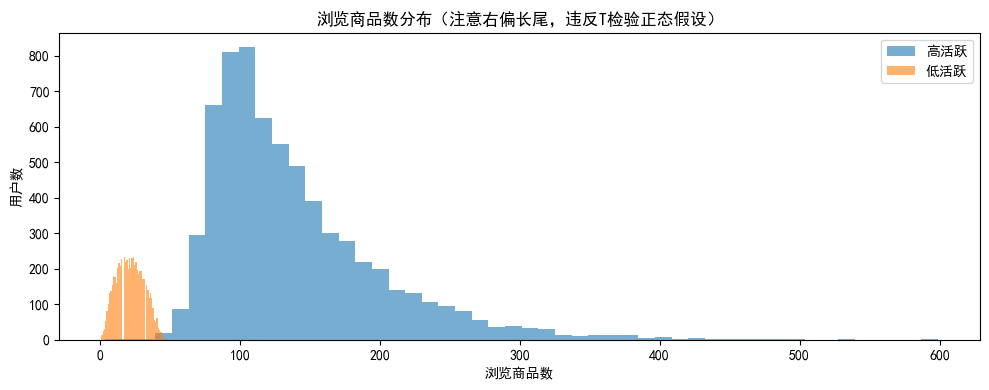

In [ ]:
# 验证正态性假设
# Shapiro检验：H0=数据服从正态分布。若 p<0.05 则拒绝正态假设。

sample_for_test = high_group.sample(min(5000, len(high_group)), random_state=42)
shapiro_stat, shapiro_p = shapiro(sample_for_test)
print(f"高活跃组正态性检验 Shapiro p值={shapiro_p:.6f}")

# 画直方图
plt.figure(figsize=(10, 4))
plt.hist(high_group, bins=50, alpha=0.6, label='高活跃')
plt.hist(low_group, bins=50, alpha=0.6, label='低活跃')
plt.title('浏览商品数分布（注意右偏长尾，违反T检验正态假设）')
plt.xlabel('浏览商品数'); plt.ylabel('用户数'); plt.legend()
plt.tight_layout(); plt.show()

# 右偏长尾，不符合正态假设，改用非参数的Mann-Whitney U 检验

In [ ]:

# Mann-Whitney U 检验
u_stat, u_p = mannwhitneyu(high_group, low_group, alternative='two-sided')
print(f"U统计量={u_stat:.1f}, p值={u_p:.6f}")
print(f"高活跃组浏览商品数中位数：{high_group.median():.0f}")
print(f"低活跃组浏览商品数中位数：{low_group.median():.0f}")

if u_p < 0.05:
    print("结论：两组浏览深度存在统计显著差异。")
    print("洞察：结合中位数判断高活跃用户是广撒网还是精准浏览，指导推荐策略。")
else:
    print("结论：无足够证据表明两组浏览深度有差异。")

# Bootstrap 自助法估计差异的置信区间
def bootstrap_diff(group_a, group_b, n_iter=2000):
    diffs = []
    a = group_a.values; b = group_b.values
    for _ in range(n_iter):
        # 有放回地重采样，模拟"重复做很多次实验"
        sample_a = np.random.choice(a, size=len(a), replace=True)
        sample_b = np.random.choice(b, size=len(b), replace=True)
        diffs.append(sample_a.mean() - sample_b.mean())
    return np.percentile(diffs, [2.5, 97.5])  # 95% 置信区间

ci_low, ci_high = bootstrap_diff(high_group, low_group)
print(f"\nBootstrap 95%置信区间（高-低 均值差）：[{ci_low:.2f}, {ci_high:.2f}]")
print("若区间不包含0，则差异稳健可信。")


【因数据不满足正态假设，改用 Mann-Whitney U 检验】
U统计量=42278290.5, p值=0.000000
高活跃组浏览商品数中位数：122
低活跃组浏览商品数中位数：22
结论：两组浏览深度存在统计显著差异。
洞察：结合中位数判断高活跃用户是广撒网还是精准浏览，指导推荐策略。

Bootstrap 95%置信区间（高-低 均值差）：[115.54, 118.50]
若区间不包含0，则差异稳健可信。
